# Exploratory Analysis of RDO_Optimized Dataset

This notebook provides a thorough exploratory analysis of the `rdo_optimized.csv` dataset, including:
- Data structure and quality assessment
- Statistical summaries
- Temporal patterns analysis
- Spatial distribution analysis
- Crime type analysis
- Missing data analysis
- Visualization of key patterns

## 1. Setup and Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("✓ Libraries imported successfully")

✓ Libraries imported successfully


## 2. Data Loading

In [4]:
# Load the optimized dataset
data_path = "prepol_out/rdo_optimized.csv"

print(f"Loading data from: {data_path}")
print("This may take a moment for large files...")

df = pd.read_csv(data_path, low_memory=False)

print(f"\n✓ Data loaded successfully")
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Loading data from: prepol_out/rdo_optimized.csv
This may take a moment for large files...

✓ Data loaded successfully
Dataset shape: 1,205,223 rows × 7 columns
Memory usage: 303.32 MB

✓ Data loaded successfully
Dataset shape: 1,205,223 rows × 7 columns
Memory usage: 303.32 MB


## 3. Dataset Structure Overview

In [5]:
# Display first and last rows
print("=" * 80)
print("FIRST 5 ROWS")
print("=" * 80)
display(df.head())

print("\n" + "=" * 80)
print("LAST 5 ROWS")
print("=" * 80)
display(df.tail())

print("\n" + "=" * 80)
print("COLUMN INFORMATION")
print("=" * 80)
df.info()

FIRST 5 ROWS


,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,datahora_ocorrencia,LATITUDE,LONGITUDE,ANO_BO,RUBRICA
0,2013-01-01,1910.00,2013-01-01 00:00:00-03:00,-23.50,-46.63,2013,Furto (art. 155)
1,2013-01-01,1910.00,2013-01-01 00:00:00-03:00,-23.51,-46.65,2013,Furto (art. 155)
2,2013-01-01,1910.00,2013-01-01 00:00:00-03:00,-23.55,-46.65,2013,Furto (art. 155)
3,2013-01-01,1910.00,2013-01-01 00:00:00-03:00,-23.59,-46.52,2013,Lesão corporal (art. 129)
4,2013-01-01,1910.00,2013-01-01 00:00:00-03:00,-23.54,-46.64,2013,Roubo (art. 157)



LAST 5 ROWS


,DATA_OCORRENCIA_BO,HORA_OCORRENCIA_BO,datahora_ocorrencia,LATITUDE,LONGITUDE,ANO_BO,RUBRICA
1205218,2016-12-31,1910.00,2016-12-31 23:55:00-03:00,-23.56,-46.66,2017,Furto (art. 155)
1205219,2016-12-31,1910.00,2016-12-31 23:55:00-03:00,-23.66,-46.66,2017,Roubo (art. 157)
1205220,2016-12-31,1910.00,2016-12-31 23:55:00-03:00,-23.80,-46.64,2017,Roubo (art. 157)
1205221,2016-12-31,1910.00,2016-12-31 23:59:00-03:00,-23.71,-46.69,2017,Roubo (art. 157)
1205222,2016-12-31,1910.00,2016-12-31 23:59:00-03:00,-23.48,-46.67,2017,Roubo (art. 157)



COLUMN INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1205223 entries, 0 to 1205222
Data columns (total 7 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   DATA_OCORRENCIA_BO   1205223 non-null  object 
 1   HORA_OCORRENCIA_BO   1205223 non-null  float64
 2   datahora_ocorrencia  1205223 non-null  object 
 3   LATITUDE             1205223 non-null  float64
 4   LONGITUDE            1205223 non-null  float64
 5   ANO_BO               1205223 non-null  int64  
 6   RUBRICA              1205223 non-null  object 
dtypes: float64(3), int64(1), object(3)
memory usage: 64.4+ MB


In [6]:
# Data types analysis
print("=" * 80)
print("DATA TYPES SUMMARY")
print("=" * 80)

dtype_counts = df.dtypes.value_counts()
print("\nColumns by data type:")
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} columns")

print("\n" + "-" * 80)
print("Columns grouped by type:")
print("-" * 80)

for dtype in dtype_counts.index:
    cols = df.select_dtypes(include=[dtype]).columns.tolist()
    print(f"\n{dtype} ({len(cols)} columns):")
    for i, col in enumerate(cols, 1):
        print(f"  {i:2d}. {col}")
        if i >= 20:  # Limit display
            remaining = len(cols) - i
            if remaining > 0:
                print(f"  ... and {remaining} more")
            break

DATA TYPES SUMMARY

Columns by data type:
  object: 3 columns
  float64: 3 columns
  int64: 1 columns

--------------------------------------------------------------------------------
Columns grouped by type:
--------------------------------------------------------------------------------

object (3 columns):
   1. DATA_OCORRENCIA_BO
   2. datahora_ocorrencia
   3. RUBRICA

float64 (3 columns):
   1. HORA_OCORRENCIA_BO
   2. LATITUDE
   3. LONGITUDE

int64 (1 columns):
   1. ANO_BO


## 4. Missing Data Analysis

In [7]:
# Comprehensive missing data analysis
print("=" * 80)
print("MISSING DATA REPORT")
print("=" * 80)

# Calculate missing values
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df) * 100),
    'Data_Type': df.dtypes,
    'Non_Null_Count': df.notnull().sum()
})

missing_stats = missing_stats.sort_values('Missing_Percent', ascending=False)
missing_stats['Missing_Percent'] = missing_stats['Missing_Percent'].round(2)

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"\nColumns with missing data: {(missing_stats['Missing_Count'] > 0).sum()}")
print(f"Columns with complete data: {(missing_stats['Missing_Count'] == 0).sum()}")

print("\n" + "-" * 80)
print("TOP 20 COLUMNS WITH MISSING VALUES")
print("-" * 80)
display(missing_stats[missing_stats['Missing_Count'] > 0].head(20))

# Identify columns with critical missing data
critical_threshold = 50
critical_missing = missing_stats[missing_stats['Missing_Percent'] > critical_threshold]
if len(critical_missing) > 0:
    print(f"\n⚠️  WARNING: {len(critical_missing)} columns have > {critical_threshold}% missing data:")
    for idx, row in critical_missing.iterrows():
        print(f"  - {row['Column']}: {row['Missing_Percent']:.2f}% missing")

MISSING DATA REPORT

Total rows: 1,205,223
Total columns: 7

Columns with missing data: 0
Columns with complete data: 7

--------------------------------------------------------------------------------
TOP 20 COLUMNS WITH MISSING VALUES
--------------------------------------------------------------------------------

Total rows: 1,205,223
Total columns: 7

Columns with missing data: 0
Columns with complete data: 7

--------------------------------------------------------------------------------
TOP 20 COLUMNS WITH MISSING VALUES
--------------------------------------------------------------------------------


,Column,Missing_Count,Missing_Percent,Data_Type,Non_Null_Count


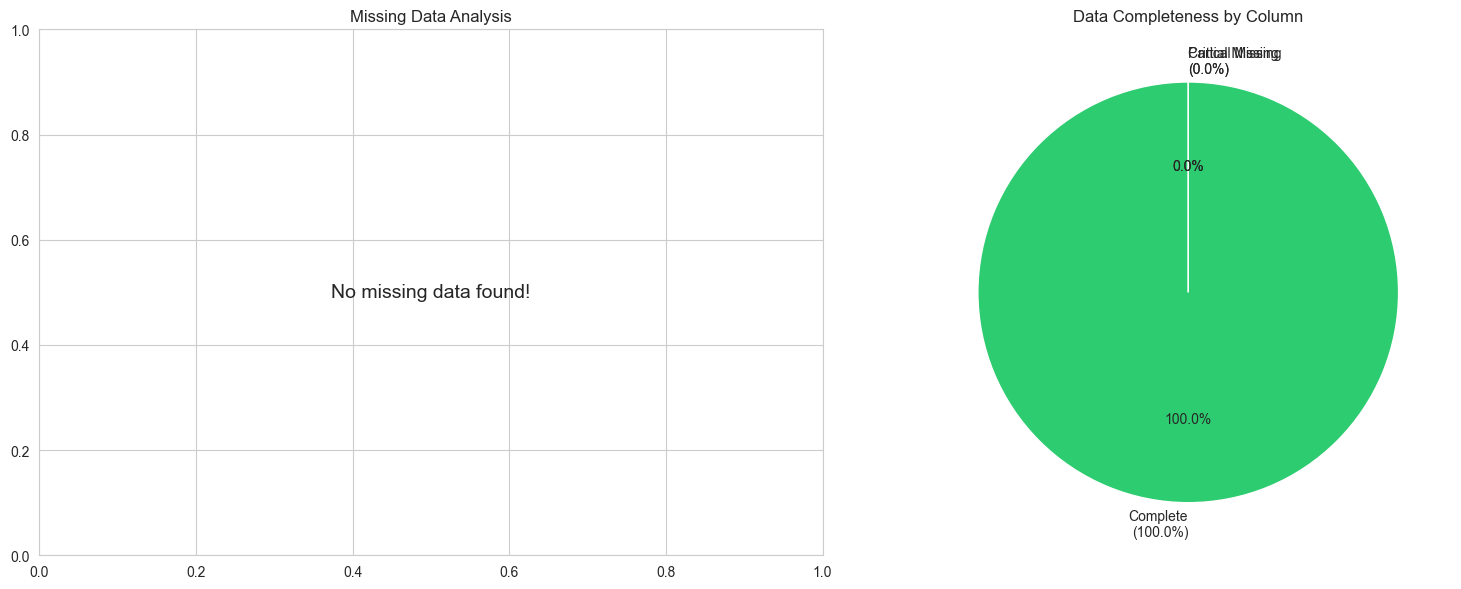


✓ Missing data visualization complete


In [8]:
# Visualize missing data
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Missing data percentage for top columns
top_missing = missing_stats[missing_stats['Missing_Count'] > 0].head(15)
if len(top_missing) > 0:
    axes[0].barh(range(len(top_missing)), top_missing['Missing_Percent'])
    axes[0].set_yticks(range(len(top_missing)))
    axes[0].set_yticklabels(top_missing['Column'])
    axes[0].set_xlabel('Missing Percentage (%)')
    axes[0].set_title('Top 15 Columns with Missing Data')
    axes[0].invert_yaxis()
    
    # Add percentage labels
    for i, v in enumerate(top_missing['Missing_Percent']):
        axes[0].text(v + 0.5, i, f'{v:.1f}%', va='center')
else:
    axes[0].text(0.5, 0.5, 'No missing data found!', 
                ha='center', va='center', transform=axes[0].transAxes, fontsize=14)
    axes[0].set_title('Missing Data Analysis')

# Plot 2: Overall data completeness
complete_pct = (missing_stats['Missing_Count'] == 0).sum() / len(missing_stats) * 100
partial_pct = ((missing_stats['Missing_Count'] > 0) & 
               (missing_stats['Missing_Percent'] < 50)).sum() / len(missing_stats) * 100
critical_pct = (missing_stats['Missing_Percent'] >= 50).sum() / len(missing_stats) * 100

sizes = [complete_pct, partial_pct, critical_pct]
labels = [f'Complete\n({complete_pct:.1f}%)', 
          f'Partial Missing\n({partial_pct:.1f}%)', 
          f'Critical Missing\n({critical_pct:.1f}%)']
colors = ['#2ecc71', '#f39c12', '#e74c3c']

axes[1].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Data Completeness by Column')

plt.tight_layout()
plt.show()

print(f"\n✓ Missing data visualization complete")

## 5. Statistical Summary

In [9]:
# Numerical columns summary
print("=" * 80)
print("NUMERICAL COLUMNS STATISTICAL SUMMARY")
print("=" * 80)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nTotal numerical columns: {len(numeric_cols)}")

if len(numeric_cols) > 0:
    print("\nDetailed statistics:")
    display(df[numeric_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T)
    
    # Additional statistics
    print("\n" + "-" * 80)
    print("ADDITIONAL STATISTICS")
    print("-" * 80)
    
    additional_stats = pd.DataFrame({
        'Column': numeric_cols,
        'Skewness': [df[col].skew() for col in numeric_cols],
        'Kurtosis': [df[col].kurtosis() for col in numeric_cols],
        'Zeros_Count': [(df[col] == 0).sum() for col in numeric_cols],
        'Zeros_Percent': [(df[col] == 0).sum() / len(df) * 100 for col in numeric_cols],
        'Unique_Values': [df[col].nunique() for col in numeric_cols]
    })
    
    additional_stats['Skewness'] = additional_stats['Skewness'].round(3)
    additional_stats['Kurtosis'] = additional_stats['Kurtosis'].round(3)
    additional_stats['Zeros_Percent'] = additional_stats['Zeros_Percent'].round(2)
    
    display(additional_stats)
else:
    print("\nNo numerical columns found in the dataset.")

NUMERICAL COLUMNS STATISTICAL SUMMARY

Total numerical columns: 4

Detailed statistics:


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
HORA_OCORRENCIA_BO,1205223.00,1910.00,0.00,1910.00,1910.00,1910.00,1910.00,1910.00,1910.00,1910.00,1910.00,1910.00
LATITUDE,1205223.00,-23.57,0.07,-23.87,-23.76,-23.69,-23.61,-23.56,-23.52,-23.47,-23.44,-23.26
LONGITUDE,1205223.00,-46.62,0.10,-47.04,-46.79,-46.76,-46.69,-46.64,-46.56,-46.42,-46.39,-46.17
ANO_BO,1205223.00,2014.67,1.18,2013.00,2013.00,2013.00,2014.00,2015.00,2016.00,2016.00,2016.00,2017.00



--------------------------------------------------------------------------------
ADDITIONAL STATISTICS
--------------------------------------------------------------------------------


,Column,Skewness,Kurtosis,Zeros_Count,Zeros_Percent,Unique_Values
0,HORA_OCORRENCIA_BO,0.00,0.00,0,0.00,1
1,LATITUDE,-0.64,0.47,0,0.00,590001
2,LONGITUDE,0.58,-0.44,0,0.00,592124
3,ANO_BO,-0.18,-1.43,0,0.00,5


In [10]:
# Categorical columns summary
print("=" * 80)
print("CATEGORICAL COLUMNS SUMMARY")
print("=" * 80)

categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\nTotal categorical columns: {len(categorical_cols)}")

if len(categorical_cols) > 0:
    cat_summary = pd.DataFrame({
        'Column': categorical_cols,
        'Unique_Values': [df[col].nunique() for col in categorical_cols],
        'Most_Common': [df[col].mode()[0] if len(df[col].mode()) > 0 else None for col in categorical_cols],
        'Most_Common_Freq': [df[col].value_counts().iloc[0] if len(df[col].value_counts()) > 0 else 0 for col in categorical_cols],
        'Most_Common_Pct': [(df[col].value_counts().iloc[0] / len(df) * 100) if len(df[col].value_counts()) > 0 else 0 for col in categorical_cols]
    })
    
    cat_summary = cat_summary.sort_values('Unique_Values', ascending=False)
    cat_summary['Most_Common_Pct'] = cat_summary['Most_Common_Pct'].round(2)
    
    display(cat_summary)
    
    # Show distribution for low-cardinality categorical columns
    print("\n" + "-" * 80)
    print("DETAILED VALUE COUNTS (for columns with ≤ 20 unique values)")
    print("-" * 80)
    
    low_card_cols = cat_summary[cat_summary['Unique_Values'] <= 20]['Column'].tolist()
    for col in low_card_cols[:10]:  # Limit to first 10
        print(f"\n{col}:")
        value_counts = df[col].value_counts()
        for val, count in value_counts.items():
            pct = count / len(df) * 100
            print(f"  {val}: {count:,} ({pct:.2f}%)")
else:
    print("\nNo categorical columns found in the dataset.")

CATEGORICAL COLUMNS SUMMARY

Total categorical columns: 3


,Column,Unique_Values,Most_Common,Most_Common_Freq,Most_Common_Pct
1,datahora_ocorrencia,282295,2016-01-30 00:00:00-03:00,721,0.06
0,DATA_OCORRENCIA_BO,1461,2016-10-21,1564,0.13
2,RUBRICA,32,Roubo (art. 157),550799,45.70



--------------------------------------------------------------------------------
DETAILED VALUE COUNTS (for columns with ≤ 20 unique values)
--------------------------------------------------------------------------------


## 6. Temporal Analysis

In [11]:
# Identify and analyze temporal columns
print("=" * 80)
print("TEMPORAL ANALYSIS")
print("=" * 80)

# Try to identify date/time columns
date_cols = []
for col in df.columns:
    if 'data' in col.lower() or 'date' in col.lower() or 'hora' in col.lower() or 'time' in col.lower():
        date_cols.append(col)

print(f"\nIdentified temporal columns: {date_cols}")

# Convert and analyze DATA_OCORRENCIA_BO if exists
if 'DATA_OCORRENCIA_BO' in df.columns:
    print("\n" + "-" * 80)
    print("DATA_OCORRENCIA_BO Analysis")
    print("-" * 80)
    
    # Try to parse the date
    try:
        df['DATA_OCORRENCIA_BO_PARSED'] = pd.to_datetime(df['DATA_OCORRENCIA_BO'], errors='coerce')
        
        # Extract temporal components
        df['Year'] = df['DATA_OCORRENCIA_BO_PARSED'].dt.year
        df['Month'] = df['DATA_OCORRENCIA_BO_PARSED'].dt.month
        df['Day'] = df['DATA_OCORRENCIA_BO_PARSED'].dt.day
        df['DayOfWeek'] = df['DATA_OCORRENCIA_BO_PARSED'].dt.dayofweek
        df['DayName'] = df['DATA_OCORRENCIA_BO_PARSED'].dt.day_name()
        df['Quarter'] = df['DATA_OCORRENCIA_BO_PARSED'].dt.quarter
        
        valid_dates = df['DATA_OCORRENCIA_BO_PARSED'].notna().sum()
        print(f"\nValid dates: {valid_dates:,} ({valid_dates/len(df)*100:.2f}%)")
        print(f"Invalid dates: {df['DATA_OCORRENCIA_BO_PARSED'].isna().sum():,}")
        
        if valid_dates > 0:
            min_date = df['DATA_OCORRENCIA_BO_PARSED'].min()
            max_date = df['DATA_OCORRENCIA_BO_PARSED'].max()
            date_range = (max_date - min_date).days
            
            print(f"\nDate range: {min_date.strftime('%Y-%m-%d')} to {max_date.strftime('%Y-%m-%d')}")
            print(f"Total span: {date_range} days ({date_range/365.25:.2f} years)")
            
            print("\n" + "-" * 80)
            print("Records by Year:")
            year_counts = df['Year'].value_counts().sort_index()
            for year, count in year_counts.items():
                if pd.notna(year):
                    print(f"  {int(year)}: {count:,} records ({count/len(df)*100:.2f}%)")
    
    except Exception as e:
        print(f"Error parsing dates: {e}")
else:
    print("\nDATA_OCORRENCIA_BO column not found in dataset.")

TEMPORAL ANALYSIS

Identified temporal columns: ['DATA_OCORRENCIA_BO', 'HORA_OCORRENCIA_BO', 'datahora_ocorrencia']

--------------------------------------------------------------------------------
DATA_OCORRENCIA_BO Analysis
--------------------------------------------------------------------------------

Valid dates: 1,205,223 (100.00%)
Invalid dates: 0

Date range: 2013-01-01 to 2016-12-31
Total span: 1460 days (4.00 years)

--------------------------------------------------------------------------------
Records by Year:
  2013: 278,024 records (23.07%)
  2014: 262,428 records (21.77%)
  2015: 251,676 records (20.88%)
  2016: 413,095 records (34.28%)

Valid dates: 1,205,223 (100.00%)
Invalid dates: 0

Date range: 2013-01-01 to 2016-12-31
Total span: 1460 days (4.00 years)

--------------------------------------------------------------------------------
Records by Year:
  2013: 278,024 records (23.07%)
  2014: 262,428 records (21.77%)
  2015: 251,676 records (20.88%)
  2016: 413,095 

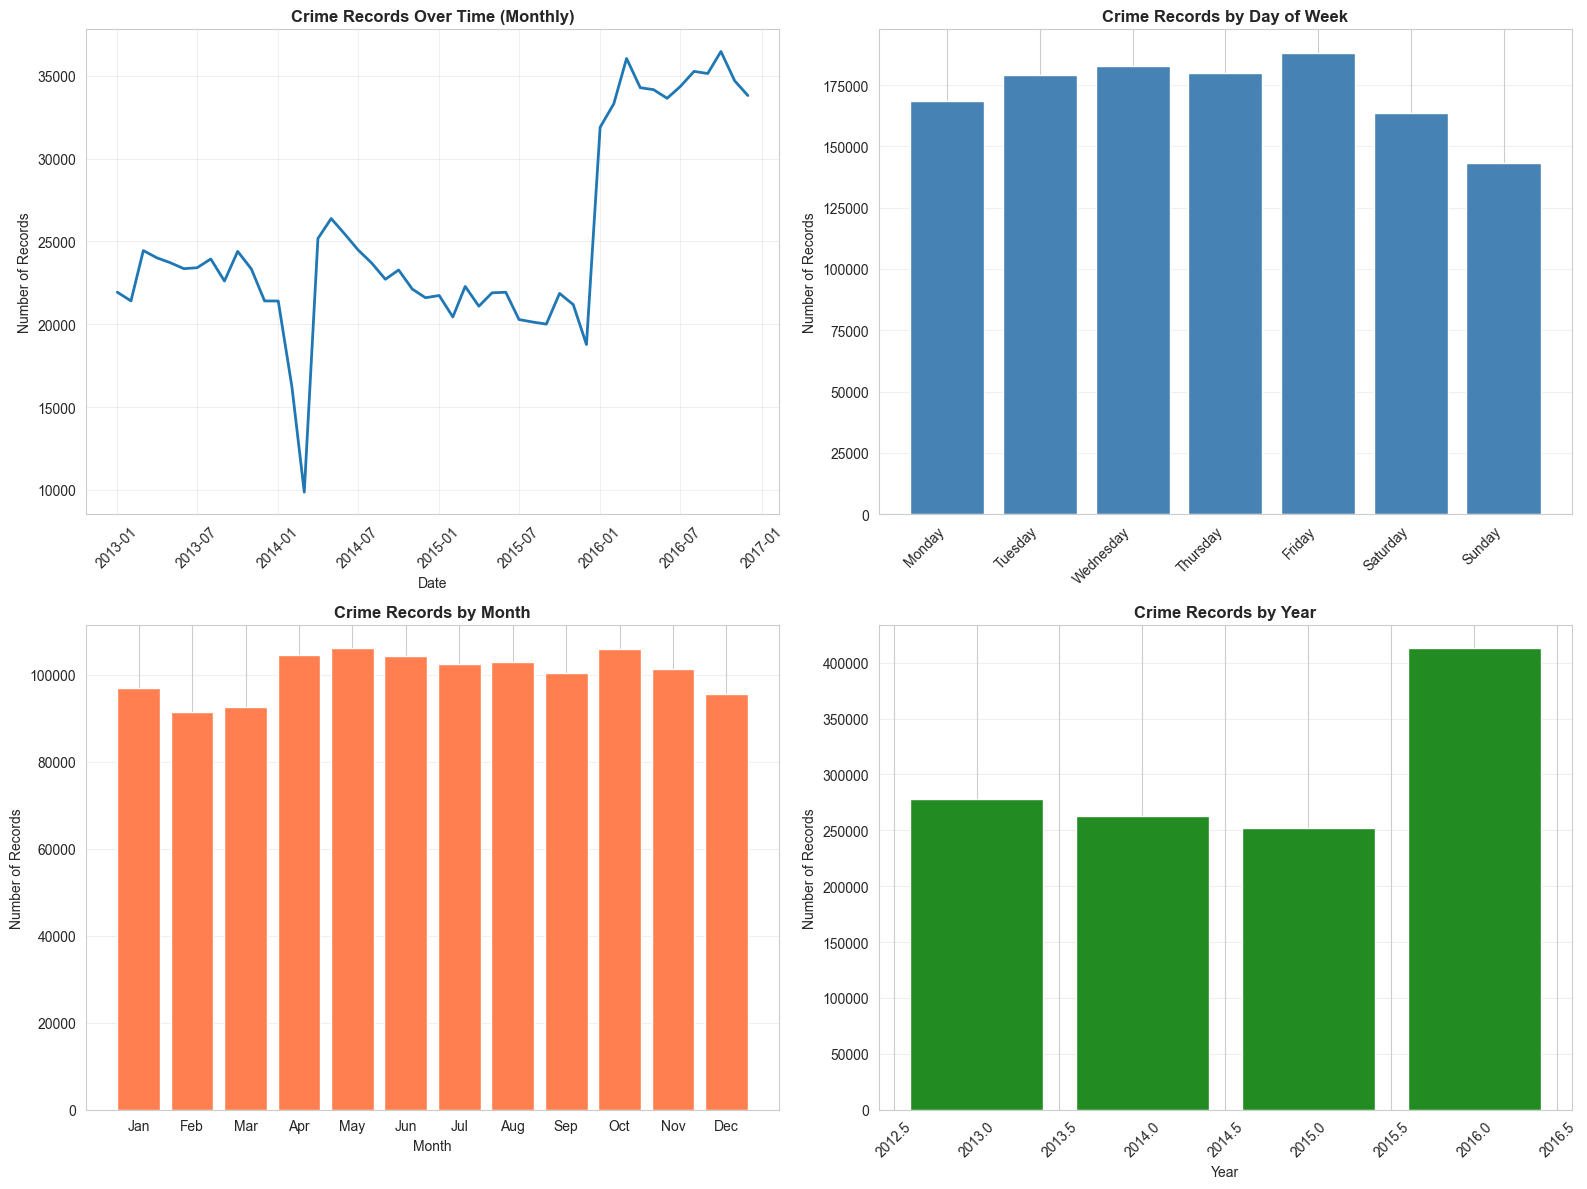

✓ Temporal visualizations complete


In [12]:
# Temporal visualizations
if 'DATA_OCORRENCIA_BO_PARSED' in df.columns and df['DATA_OCORRENCIA_BO_PARSED'].notna().sum() > 0:
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Records over time (monthly)
    df_temp = df[df['DATA_OCORRENCIA_BO_PARSED'].notna()].copy()
    df_temp['YearMonth'] = df_temp['DATA_OCORRENCIA_BO_PARSED'].dt.to_period('M')
    monthly_counts = df_temp.groupby('YearMonth').size()
    
    axes[0, 0].plot(monthly_counts.index.to_timestamp(), monthly_counts.values, linewidth=2)
    axes[0, 0].set_title('Crime Records Over Time (Monthly)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Number of Records')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].tick_params(axis='x', rotation=45)
    
    # Plot 2: Records by day of week
    if 'DayName' in df.columns:
        day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
        day_counts = df['DayName'].value_counts().reindex(day_order, fill_value=0)
        
        axes[0, 1].bar(range(len(day_counts)), day_counts.values, color='steelblue')
        axes[0, 1].set_xticks(range(len(day_counts)))
        axes[0, 1].set_xticklabels(day_counts.index, rotation=45, ha='right')
        axes[0, 1].set_title('Crime Records by Day of Week', fontsize=12, fontweight='bold')
        axes[0, 1].set_ylabel('Number of Records')
        axes[0, 1].grid(True, alpha=0.3, axis='y')
    
    # Plot 3: Records by month
    if 'Month' in df.columns:
        month_counts = df['Month'].value_counts().sort_index()
        month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
        
        axes[1, 0].bar(month_counts.index, month_counts.values, color='coral')
        axes[1, 0].set_xticks(range(1, 13))
        axes[1, 0].set_xticklabels(month_names)
        axes[1, 0].set_title('Crime Records by Month', fontsize=12, fontweight='bold')
        axes[1, 0].set_xlabel('Month')
        axes[1, 0].set_ylabel('Number of Records')
        axes[1, 0].grid(True, alpha=0.3, axis='y')
    
    # Plot 4: Records by year
    if 'Year' in df.columns:
        year_counts = df['Year'].value_counts().sort_index()
        year_counts = year_counts[year_counts.index.notna()]
        
        axes[1, 1].bar(year_counts.index, year_counts.values, color='forestgreen')
        axes[1, 1].set_title('Crime Records by Year', fontsize=12, fontweight='bold')
        axes[1, 1].set_xlabel('Year')
        axes[1, 1].set_ylabel('Number of Records')
        axes[1, 1].grid(True, alpha=0.3, axis='y')
        axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Temporal visualizations complete")
else:
    print("Temporal data not available for visualization.")

## 7. Spatial Analysis (Geographic Coordinates)

In [13]:
# Spatial data analysis
print("=" * 80)
print("SPATIAL DATA ANALYSIS")
print("=" * 80)

has_lat = 'LATITUDE' in df.columns
has_lon = 'LONGITUDE' in df.columns

print(f"\nLATITUDE column exists: {has_lat}")
print(f"LONGITUDE column exists: {has_lon}")

if has_lat and has_lon:
    # Basic statistics
    valid_coords = df[(df['LATITUDE'].notna()) & (df['LONGITUDE'].notna())]
    total_records = len(df)
    valid_count = len(valid_coords)
    
    print(f"\nTotal records: {total_records:,}")
    print(f"Records with valid coordinates: {valid_count:,} ({valid_count/total_records*100:.2f}%)")
    print(f"Records with missing coordinates: {total_records - valid_count:,} ({(total_records-valid_count)/total_records*100:.2f}%)")
    
    if valid_count > 0:
        print("\n" + "-" * 80)
        print("COORDINATE RANGES")
        print("-" * 80)
        print(f"\nLatitude:")
        print(f"  Min: {valid_coords['LATITUDE'].min():.6f}")
        print(f"  Max: {valid_coords['LATITUDE'].max():.6f}")
        print(f"  Mean: {valid_coords['LATITUDE'].mean():.6f}")
        print(f"  Median: {valid_coords['LATITUDE'].median():.6f}")
        
        print(f"\nLongitude:")
        print(f"  Min: {valid_coords['LONGITUDE'].min():.6f}")
        print(f"  Max: {valid_coords['LONGITUDE'].max():.6f}")
        print(f"  Mean: {valid_coords['LONGITUDE'].mean():.6f}")
        print(f"  Median: {valid_coords['LONGITUDE'].median():.6f}")
        
        # Check for outliers (basic geographic validation)
        # Assuming data is from São Paulo, Brazil region
        # Valid ranges approximately: Lat -24.5 to -22.5, Lon -48.5 to -45.5
        outliers_lat = ((valid_coords['LATITUDE'] < -30) | (valid_coords['LATITUDE'] > -20)).sum()
        outliers_lon = ((valid_coords['LONGITUDE'] < -55) | (valid_coords['LONGITUDE'] > -40)).sum()
        
        print("\n" + "-" * 80)
        print("POTENTIAL COORDINATE OUTLIERS")
        print("-" * 80)
        print(f"Latitude outliers (outside -30 to -20): {outliers_lat:,} ({outliers_lat/valid_count*100:.2f}%)")
        print(f"Longitude outliers (outside -55 to -40): {outliers_lon:,} ({outliers_lon/valid_count*100:.2f}%)")
        
        # Identify duplicate coordinates
        coord_duplicates = valid_coords.groupby(['LATITUDE', 'LONGITUDE']).size()
        duplicate_locs = coord_duplicates[coord_duplicates > 1]
        
        print("\n" + "-" * 80)
        print("COORDINATE DUPLICATES")
        print("-" * 80)
        print(f"Unique coordinate pairs: {len(coord_duplicates):,}")
        print(f"Duplicate locations: {len(duplicate_locs):,}")
        if len(duplicate_locs) > 0:
            print(f"\nTop 10 most common locations:")
            for (lat, lon), count in duplicate_locs.nlargest(10).items():
                print(f"  ({lat:.6f}, {lon:.6f}): {count:,} occurrences")
else:
    print("\n⚠️  Coordinate columns (LATITUDE, LONGITUDE) not found in dataset.")

SPATIAL DATA ANALYSIS

LATITUDE column exists: True
LONGITUDE column exists: True

Total records: 1,205,223
Records with valid coordinates: 1,205,223 (100.00%)
Records with missing coordinates: 0 (0.00%)

--------------------------------------------------------------------------------
COORDINATE RANGES
--------------------------------------------------------------------------------

Latitude:
  Min: -23.871556
  Max: -23.262443
  Mean: -23.569086
  Median: -23.555811

Longitude:
  Min: -47.037189
  Max: -46.173815
  Mean: -46.618300
  Median: -46.638780

--------------------------------------------------------------------------------
POTENTIAL COORDINATE OUTLIERS
--------------------------------------------------------------------------------
Latitude outliers (outside -30 to -20): 0 (0.00%)
Longitude outliers (outside -55 to -40): 0 (0.00%)
  Median: -46.638780

--------------------------------------------------------------------------------
POTENTIAL COORDINATE OUTLIERS
-------------

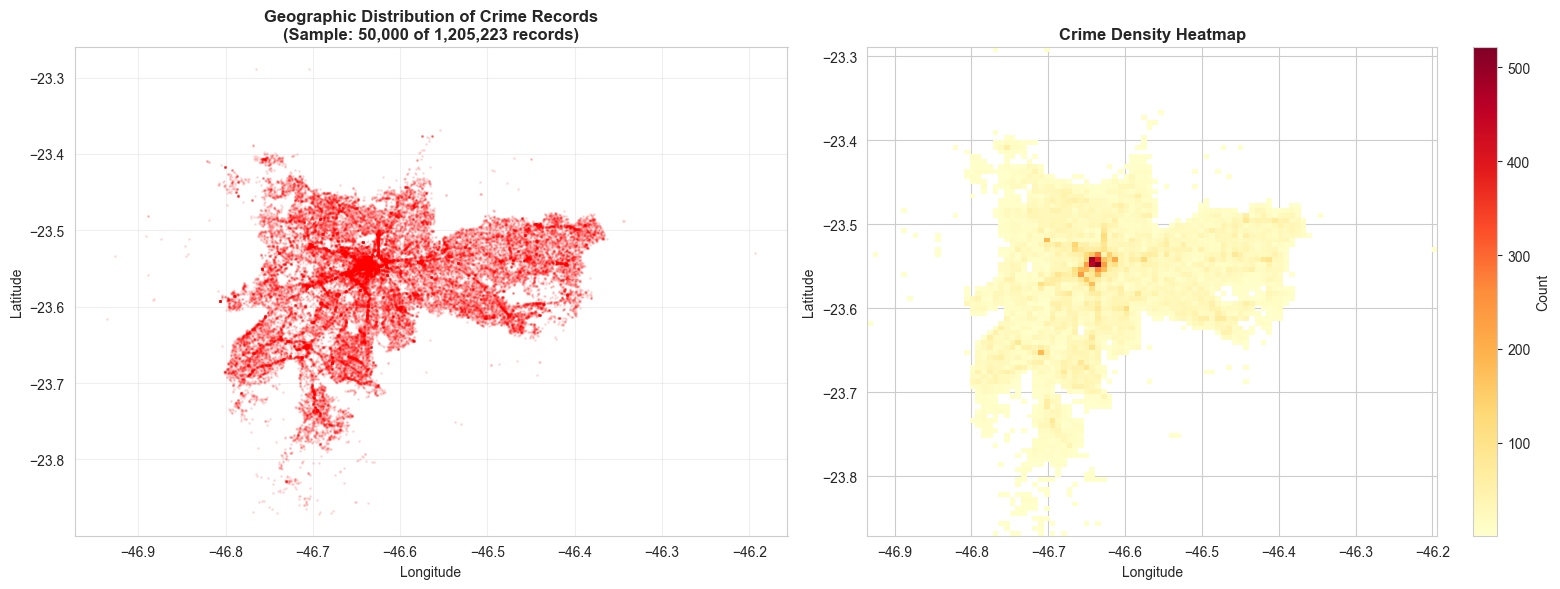

✓ Spatial visualizations complete


In [14]:
# Spatial visualizations
if has_lat and has_lon and valid_count > 0:
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Sample data for plotting if dataset is too large
    plot_sample = valid_coords.sample(n=min(50000, len(valid_coords)), random_state=42)
    
    # Plot 1: Scatter plot of coordinates
    axes[0].scatter(plot_sample['LONGITUDE'], plot_sample['LATITUDE'], 
                   alpha=0.1, s=1, c='red')
    axes[0].set_xlabel('Longitude')
    axes[0].set_ylabel('Latitude')
    axes[0].set_title(f'Geographic Distribution of Crime Records\n(Sample: {len(plot_sample):,} of {valid_count:,} records)', 
                     fontsize=12, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: 2D Density histogram
    axes[1].hist2d(plot_sample['LONGITUDE'], plot_sample['LATITUDE'], 
                  bins=100, cmap='YlOrRd', cmin=1)
    axes[1].set_xlabel('Longitude')
    axes[1].set_ylabel('Latitude')
    axes[1].set_title('Crime Density Heatmap', fontsize=12, fontweight='bold')
    plt.colorbar(axes[1].collections[0], ax=axes[1], label='Count')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Spatial visualizations complete")
else:
    print("Spatial data not available for visualization.")

## 8. Crime Type Analysis

In [15]:
# Crime type analysis
print("=" * 80)
print("CRIME TYPE ANALYSIS")
print("=" * 80)

crime_cols = ['DESCR_TIPO_BO', 'RUBRICA', 'DESCR_CONDUTA', 'DESDOBRAMENTO']
available_crime_cols = [col for col in crime_cols if col in df.columns]

print(f"\nCrime-related columns found: {available_crime_cols}")

for col in available_crime_cols[:2]:  # Focus on first 2 most important
    print("\n" + "=" * 80)
    print(f"{col} DISTRIBUTION")
    print("=" * 80)
    
    # Value counts
    value_counts = df[col].value_counts()
    total_valid = value_counts.sum()
    
    print(f"\nTotal unique values: {len(value_counts):,}")
    print(f"Total valid records: {total_valid:,}")
    print(f"Missing records: {df[col].isna().sum():,} ({df[col].isna().sum()/len(df)*100:.2f}%)")
    
    # Top 20 most common
    print(f"\nTop 20 Most Common {col}:")
    print("-" * 80)
    for i, (val, count) in enumerate(value_counts.head(20).items(), 1):
        pct = count / total_valid * 100
        print(f"{i:2d}. {str(val)[:60]:<60} {count:>8,} ({pct:>5.2f}%)")
    
    # Distribution concentration
    top_10_pct = value_counts.head(10).sum() / total_valid * 100
    top_20_pct = value_counts.head(20).sum() / total_valid * 100
    
    print(f"\n📊 Concentration metrics:")
    print(f"  Top 10 types represent: {top_10_pct:.2f}% of all records")
    print(f"  Top 20 types represent: {top_20_pct:.2f}% of all records")

CRIME TYPE ANALYSIS

Crime-related columns found: ['RUBRICA']

RUBRICA DISTRIBUTION

Total unique values: 32
Total valid records: 1,205,223
Missing records: 0 (0.00%)

Top 20 Most Common RUBRICA:
--------------------------------------------------------------------------------
 1. Roubo (art. 157)                                              550,799 (45.70%)
 2. Furto (art. 155)                                              396,489 (32.90%)
 3. Furto qualificado (art. 155, §4o.)                             80,069 ( 6.64%)
 4. Lesão corporal culposa na direção de veículo automotor (Art.   69,161 ( 5.74%)
 5. Lesão corporal (art. 129)                                      65,493 ( 5.43%)
 6. Lesão corporal (art 129 § 9º)                                  15,330 ( 1.27%)
 7. Homicídio simples (art. 121)                                    6,019 ( 0.50%)
 8. A.I.-Roubo (art. 157)                                           5,469 ( 0.45%)
 9. A.I.-Lesão corporal (art. 129)                         

In [16]:
# Visualize crime types
if 'DESCR_TIPO_BO' in df.columns:
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Plot 1: Top crime types (bar chart)
    top_crimes = df['DESCR_TIPO_BO'].value_counts().head(15)
    
    axes[0].barh(range(len(top_crimes)), top_crimes.values, color='steelblue')
    axes[0].set_yticks(range(len(top_crimes)))
    axes[0].set_yticklabels([str(x)[:40] for x in top_crimes.index])
    axes[0].set_xlabel('Number of Records')
    axes[0].set_title('Top 15 Crime Types', fontsize=12, fontweight='bold')
    axes[0].invert_yaxis()
    
    # Add count labels
    for i, v in enumerate(top_crimes.values):
        axes[0].text(v + max(top_crimes.values)*0.01, i, f'{v:,}', va='center')
    
    # Plot 2: Crime type distribution (pie chart for top 10)
    top_10_crimes = df['DESCR_TIPO_BO'].value_counts().head(10)
    others = df['DESCR_TIPO_BO'].value_counts()[10:].sum()
    
    if others > 0:
        plot_data = list(top_10_crimes.values) + [others]
        plot_labels = [str(x)[:25] for x in top_10_crimes.index] + ['Others']
    else:
        plot_data = list(top_10_crimes.values)
        plot_labels = [str(x)[:25] for x in top_10_crimes.index]
    
    axes[1].pie(plot_data, labels=plot_labels, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Crime Type Distribution (Top 10 + Others)', fontsize=12, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ Crime type visualizations complete")
else:
    print("DESCR_TIPO_BO column not found in dataset.")

DESCR_TIPO_BO column not found in dataset.


## 9. Location Analysis

In [17]:
# Location-related columns analysis
print("=" * 80)
print("LOCATION ANALYSIS")
print("=" * 80)

location_cols = ['NOME_MUNICIPIO_CIRC', 'NOME_DELEGACIA', 'DESCR_TIPOLOCAL', 'DESCR_SUBTIPOLOCAL']
available_loc_cols = [col for col in location_cols if col in df.columns]

print(f"\nLocation columns found: {available_loc_cols}")

for col in available_loc_cols[:2]:  # Focus on first 2
    print("\n" + "=" * 80)
    print(f"{col} DISTRIBUTION")
    print("=" * 80)
    
    value_counts = df[col].value_counts()
    total_valid = value_counts.sum()
    
    print(f"\nTotal unique values: {len(value_counts):,}")
    print(f"Total valid records: {total_valid:,}")
    print(f"Missing records: {df[col].isna().sum():,} ({df[col].isna().sum()/len(df)*100:.2f}%)")
    
    print(f"\nTop 15 Most Common {col}:")
    print("-" * 80)
    for i, (val, count) in enumerate(value_counts.head(15).items(), 1):
        pct = count / total_valid * 100
        print(f"{i:2d}. {str(val)[:60]:<60} {count:>8,} ({pct:>5.2f}%)")

LOCATION ANALYSIS

Location columns found: []


## 10. Data Quality Assessment

In [18]:
# Comprehensive data quality report
print("=" * 80)
print("DATA QUALITY ASSESSMENT REPORT")
print("=" * 80)

# 1. Completeness
print("\n1. DATA COMPLETENESS")
print("-" * 80)
total_cells = df.shape[0] * df.shape[1]
missing_cells = df.isnull().sum().sum()
completeness = (1 - missing_cells / total_cells) * 100

print(f"Total data points: {total_cells:,}")
print(f"Missing data points: {missing_cells:,}")
print(f"Overall completeness: {completeness:.2f}%")

# 2. Duplicate records
print("\n2. DUPLICATE RECORDS")
print("-" * 80)
duplicates = df.duplicated().sum()
duplicate_pct = duplicates / len(df) * 100
print(f"Duplicate rows: {duplicates:,} ({duplicate_pct:.2f}%)")

if duplicates > 0:
    print("Sample duplicate records:")
    display(df[df.duplicated(keep=False)].head(5))

# 3. Data consistency
print("\n3. DATA CONSISTENCY CHECKS")
print("-" * 80)

# Check for negative values in numeric columns
print("Negative values in numeric columns:")
for col in numeric_cols[:10]:  # Check first 10 numeric columns
    neg_count = (df[col] < 0).sum()
    if neg_count > 0:
        print(f"  {col}: {neg_count:,} negative values ({neg_count/len(df)*100:.2f}%)")

# 4. Cardinality
print("\n4. CARDINALITY ANALYSIS")
print("-" * 80)
print("Columns by uniqueness:")

cardinality_stats = pd.DataFrame({
    'Column': df.columns,
    'Unique_Count': [df[col].nunique() for col in df.columns],
    'Unique_Percent': [df[col].nunique() / len(df) * 100 for col in df.columns]
})

cardinality_stats = cardinality_stats.sort_values('Unique_Percent', ascending=False)

print("\nHigh cardinality (>90% unique):")
high_card = cardinality_stats[cardinality_stats['Unique_Percent'] > 90]
for _, row in high_card.head(10).iterrows():
    print(f"  {row['Column']}: {row['Unique_Count']:,} unique ({row['Unique_Percent']:.2f}%)")

print("\nLow cardinality (<5% unique):")
low_card = cardinality_stats[cardinality_stats['Unique_Percent'] < 5]
for _, row in low_card.head(10).iterrows():
    print(f"  {row['Column']}: {row['Unique_Count']:,} unique ({row['Unique_Percent']:.2f}%)")

# 5. Summary quality score
print("\n" + "=" * 80)
print("OVERALL QUALITY SCORE")
print("=" * 80)

quality_score = 0
factors = []

# Completeness score (40 points)
completeness_score = (completeness / 100) * 40
quality_score += completeness_score
factors.append(f"Completeness: {completeness_score:.1f}/40")

# Duplicates score (30 points)
duplicate_score = (1 - duplicate_pct / 100) * 30
quality_score += duplicate_score
factors.append(f"No duplicates: {duplicate_score:.1f}/30")

# Valid coordinates score (30 points) - if applicable
if has_lat and has_lon:
    coord_score = (valid_count / len(df)) * 30
    quality_score += coord_score
    factors.append(f"Valid coordinates: {coord_score:.1f}/30")

print(f"\nOverall Quality Score: {quality_score:.1f}/100")
print("\nBreakdown:")
for factor in factors:
    print(f"  {factor}")

if quality_score >= 80:
    print("\n✅ EXCELLENT data quality")
elif quality_score >= 60:
    print("\n⚠️  GOOD data quality (some issues to address)")
elif quality_score >= 40:
    print("\n⚠️  FAIR data quality (significant issues present)")
else:
    print("\n❌ POOR data quality (major issues require attention)")

DATA QUALITY ASSESSMENT REPORT

1. DATA COMPLETENESS
--------------------------------------------------------------------------------
Total data points: 16,873,122
Missing data points: 0
Overall completeness: 100.00%

2. DUPLICATE RECORDS
--------------------------------------------------------------------------------
Total data points: 16,873,122
Missing data points: 0
Overall completeness: 100.00%

2. DUPLICATE RECORDS
--------------------------------------------------------------------------------
Duplicate rows: 0 (0.00%)

3. DATA CONSISTENCY CHECKS
--------------------------------------------------------------------------------
Negative values in numeric columns:
  LATITUDE: 1,205,223 negative values (100.00%)
  LONGITUDE: 1,205,223 negative values (100.00%)

4. CARDINALITY ANALYSIS
--------------------------------------------------------------------------------
Columns by uniqueness:
Duplicate rows: 0 (0.00%)

3. DATA CONSISTENCY CHECKS
-------------------------------------------

## 11. Correlation Analysis (Numeric Columns)

CORRELATION ANALYSIS

Strong Correlations (|r| > 0.7, excluding diagonal):
--------------------------------------------------------------------------------
  No strong correlations found.


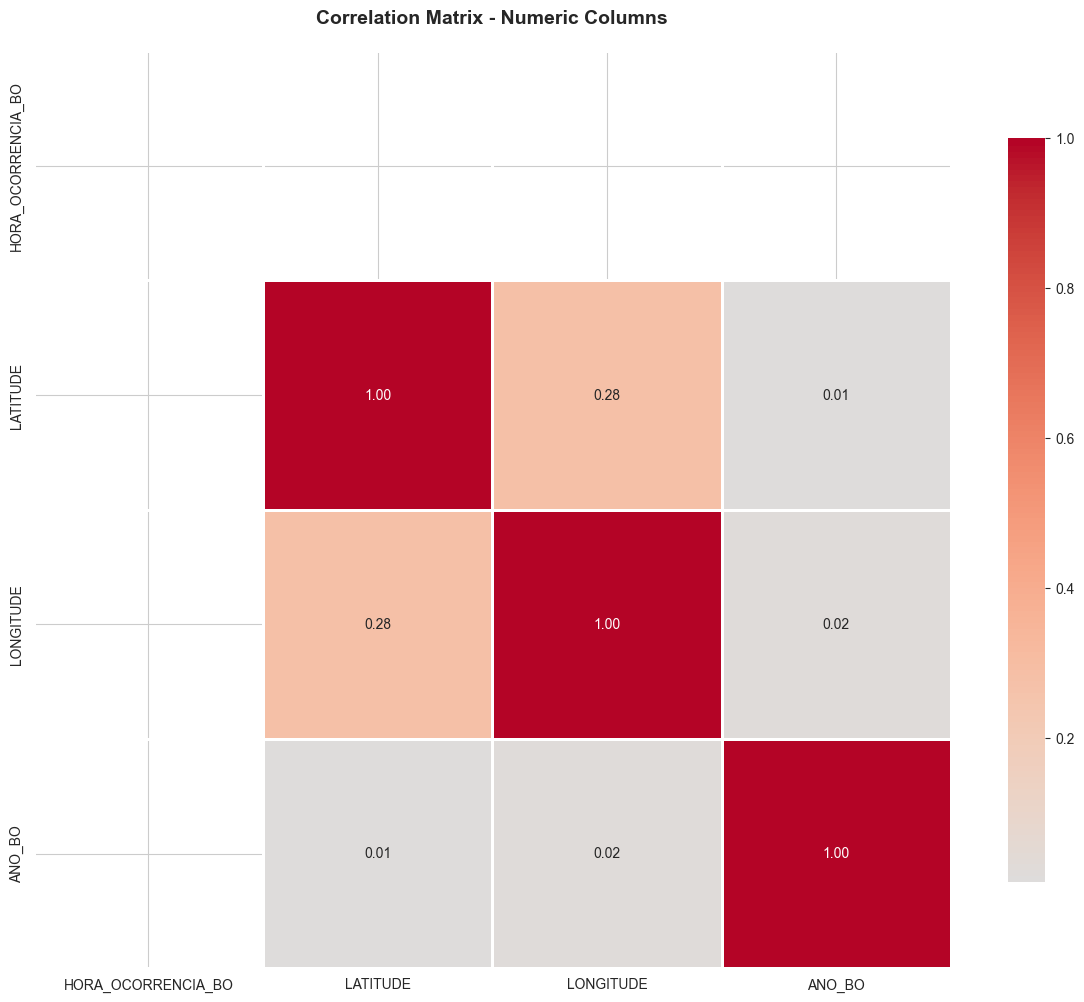


✓ Correlation matrix visualization complete


In [19]:
# Correlation analysis
if len(numeric_cols) > 1:
    print("=" * 80)
    print("CORRELATION ANALYSIS")
    print("=" * 80)
    
    # Calculate correlation matrix
    corr_matrix = df[numeric_cols].corr()
    
    # Find strong correlations
    print("\nStrong Correlations (|r| > 0.7, excluding diagonal):")
    print("-" * 80)
    
    strong_corr = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_val = corr_matrix.iloc[i, j]
            if abs(corr_val) > 0.7:
                strong_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_val))
    
    if strong_corr:
        for col1, col2, corr_val in sorted(strong_corr, key=lambda x: abs(x[2]), reverse=True):
            print(f"  {col1} <-> {col2}: {corr_val:.3f}")
    else:
        print("  No strong correlations found.")
    
    # Visualize correlation matrix
    if len(numeric_cols) <= 20:  # Only plot if reasonable number of columns
        fig, ax = plt.subplots(figsize=(12, 10))
        
        sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                   center=0, square=True, linewidths=1, 
                   cbar_kws={"shrink": 0.8}, ax=ax)
        
        ax.set_title('Correlation Matrix - Numeric Columns', fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        print("\n✓ Correlation matrix visualization complete")
    else:
        print(f"\n⚠️  Too many numeric columns ({len(numeric_cols)}) for readable correlation matrix visualization.")
        print("Showing top 15 columns by variance:")
        
        # Select top columns by variance
        variances = df[numeric_cols].var().sort_values(ascending=False)
        top_cols = variances.head(15).index.tolist()
        
        fig, ax = plt.subplots(figsize=(12, 10))
        sns.heatmap(df[top_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
                   center=0, square=True, linewidths=1,
                   cbar_kws={"shrink": 0.8}, ax=ax)
        
        ax.set_title('Correlation Matrix - Top 15 Numeric Columns by Variance', 
                    fontsize=14, fontweight='bold', pad=20)
        plt.tight_layout()
        plt.show()
        
        print("✓ Correlation matrix visualization complete")
else:
    print("Insufficient numeric columns for correlation analysis.")

## 12. Summary Statistics Export

In [20]:
# Create comprehensive summary report
print("=" * 80)
print("GENERATING SUMMARY REPORT")
print("=" * 80)

# Compile key statistics
summary_report = {
    'Dataset': 'rdo_optimized.csv',
    'Analysis_Date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'Total_Rows': len(df),
    'Total_Columns': len(df.columns),
    'Memory_Usage_MB': df.memory_usage(deep=True).sum() / 1024**2,
    'Data_Completeness_Pct': completeness,
    'Duplicate_Rows': duplicates,
    'Duplicate_Pct': duplicate_pct,
    'Numeric_Columns': len(numeric_cols),
    'Categorical_Columns': len(categorical_cols),
}

if has_lat and has_lon:
    summary_report['Records_With_Valid_Coords'] = valid_count
    summary_report['Valid_Coords_Pct'] = (valid_count / len(df)) * 100

if 'DATA_OCORRENCIA_BO_PARSED' in df.columns and df['DATA_OCORRENCIA_BO_PARSED'].notna().sum() > 0:
    summary_report['Date_Range_Start'] = df['DATA_OCORRENCIA_BO_PARSED'].min().strftime('%Y-%m-%d')
    summary_report['Date_Range_End'] = df['DATA_OCORRENCIA_BO_PARSED'].max().strftime('%Y-%m-%d')
    summary_report['Date_Span_Days'] = (df['DATA_OCORRENCIA_BO_PARSED'].max() - df['DATA_OCORRENCIA_BO_PARSED'].min()).days

print("\nSummary Report:")
print("-" * 80)
for key, value in summary_report.items():
    if isinstance(value, float):
        print(f"{key}: {value:.2f}")
    else:
        print(f"{key}: {value}")

# Save to text file
report_filename = f"prepol_out/exploratory_report_{datetime.now().strftime('%Y%m%d_%H%M%S')}.txt"

with open(report_filename, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("RDO_OPTIMIZED EXPLORATORY ANALYSIS REPORT\n")
    f.write("=" * 80 + "\n\n")
    
    for key, value in summary_report.items():
        f.write(f"{key}: {value}\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("MISSING DATA SUMMARY\n")
    f.write("=" * 80 + "\n\n")
    f.write(missing_stats.to_string())
    
    f.write("\n\n" + "=" * 80 + "\n")
    f.write("COLUMN INFORMATION\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"Columns: {list(df.columns)}\n")

print(f"\n✅ Summary report saved to: {report_filename}")
print("\n" + "=" * 80)
print("EXPLORATORY ANALYSIS COMPLETE")
print("=" * 80)

GENERATING SUMMARY REPORT

Summary Report:
--------------------------------------------------------------------------------
Dataset: rdo_optimized.csv
Analysis_Date: 2025-11-19 16:16:52
Total_Rows: 1205223
Total_Columns: 14
Memory_Usage_MB: 419.38
Data_Completeness_Pct: 100.00
Duplicate_Rows: 0
Duplicate_Pct: 0.00
Numeric_Columns: 4
Categorical_Columns: 3
Records_With_Valid_Coords: 1205223
Valid_Coords_Pct: 100.00
Date_Range_Start: 2013-01-01
Date_Range_End: 2016-12-31
Date_Span_Days: 1460

✅ Summary report saved to: prepol_out/exploratory_report_20251119_161653.txt

EXPLORATORY ANALYSIS COMPLETE

Summary Report:
--------------------------------------------------------------------------------
Dataset: rdo_optimized.csv
Analysis_Date: 2025-11-19 16:16:52
Total_Rows: 1205223
Total_Columns: 14
Memory_Usage_MB: 419.38
Data_Completeness_Pct: 100.00
Duplicate_Rows: 0
Duplicate_Pct: 0.00
Numeric_Columns: 4
Categorical_Columns: 3
Records_With_Valid_Coords: 1205223
Valid_Coords_Pct: 100.00
Date